# 09. 多分类问题


用到 Softmax classifier

原本是十个输出，然后分别代表P(X=i),对每一个输出应用loss=-(ylogyhat+(1-y)log(1-yhat))相当于一堆二分类

但实际上应该会有互相抑制，输出理应是一个分布

所以在最后一层用一个softmax layer，e^zi使得输出>0, /Sigma用于和为1  

loss = -YlogY_pred

1、softmax的输入不需要再做非线性变换，也就是说softmax之前不再需要激活函数(relu)。softmax两个作用，如果在进行softmax前的input有负数，通过指数变换，得到正数。所有类的概率求和为1。

2、y的标签编码方式是one-hot。我对one-hot的理解是只有一位是1，其他位为0。(但是标签的one-hot编码是算法完成的，算法的输入仍为原始标签)

3、多分类问题，标签y的类型是LongTensor。比如说0-9分类问题，如果y = torch.LongTensor([3])，对应的one-hot是[0,0,0,1,0,0,0,0,0,0].(这里要注意，如果使用了one-hot，标签y的类型是LongTensor，糖尿病数据集中的target的类型是FloatTensor)

4、CrossEntropyLoss <==> LogSoftmax + NLLLoss。也就是说使用CrossEntropyLoss最后一层(线性层)是不需要做其他变化的；使用NLLLoss之前，需要对最后一层(线性层)先进行SoftMax处理，再进行log 操作。

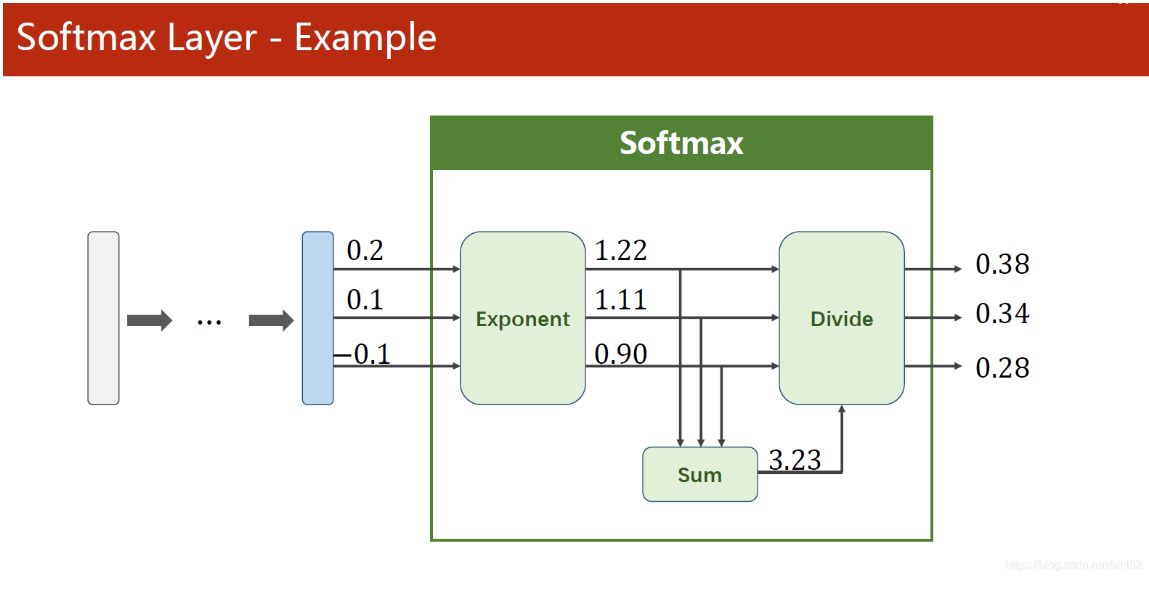

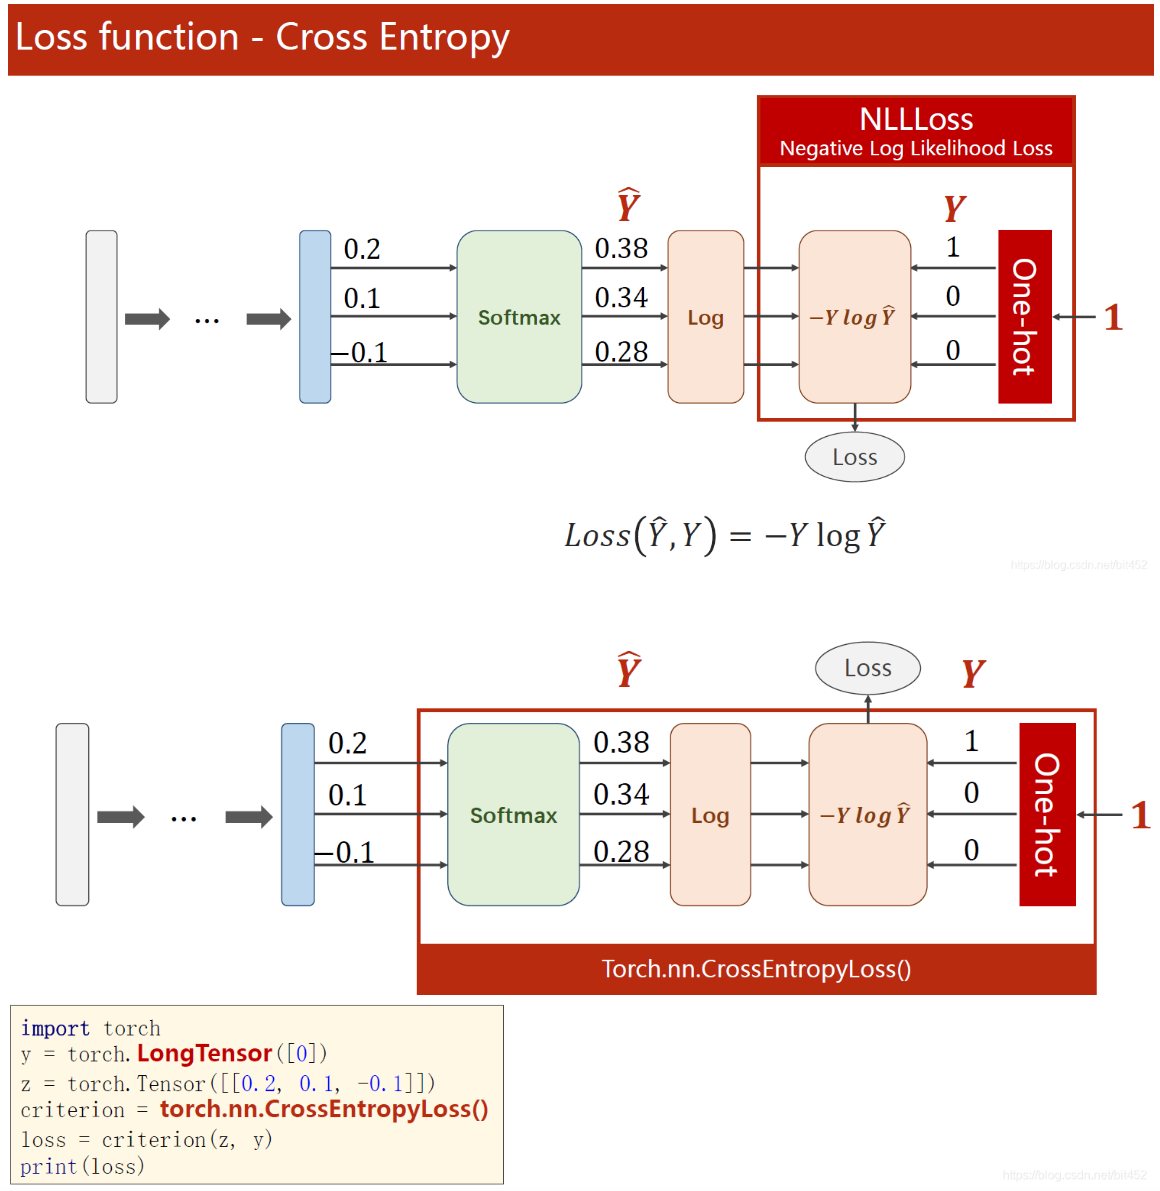



代码说明：
1、第8讲 from torch.utils.data import Dataset，第9讲 from torchvision import datasets。该datasets里面init ，getitem,len魔法函数已实现。

2、torch.max的返回值有两个，第一个是每一行的最大值是多少，第二个是每一行最大值的下标(索引)是多少。

3、全连接神经网络

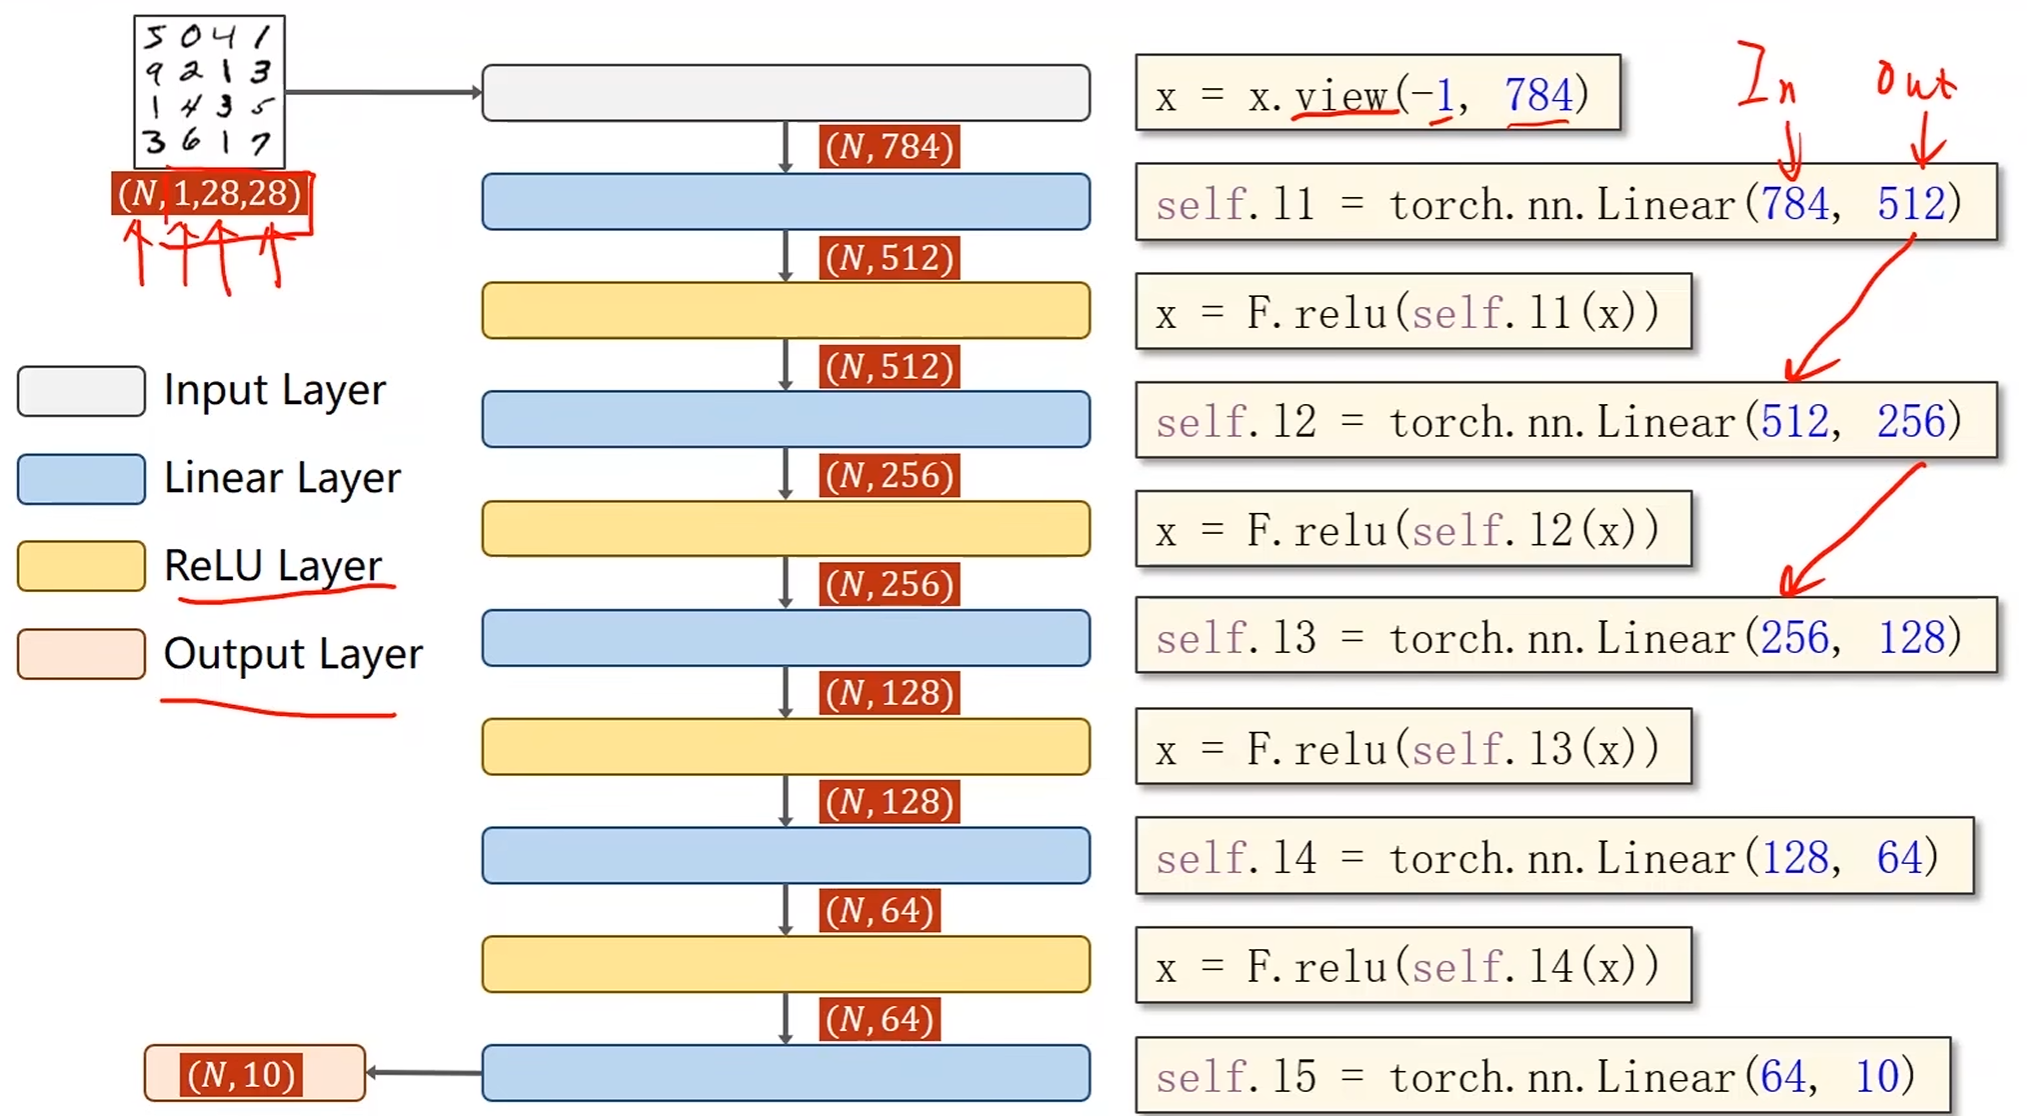

In [5]:
import torch
from torchvision import transforms
from torchvision import datasets
from torch.utils.data import DataLoader
import torch.nn.functional as F
import torch.optim as optim
 
# prepare dataset
batch_size = 64
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))]) # 归一化,减均值然后除以方差

train_dataset = datasets.MNIST(root='../dataset/mnist/', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size)
test_dataset = datasets.MNIST(root='../dataset/mnist/', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, shuffle=False, batch_size=batch_size)
 
# design model using class
class Net(torch.nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.l1 = torch.nn.Linear(784, 512)
        self.l2 = torch.nn.Linear(512, 256)
        self.l3 = torch.nn.Linear(256, 128)
        self.l4 = torch.nn.Linear(128, 64)
        self.l5 = torch.nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(-1, 784)  # -1其实就是自动获取mini_batch的batchsize
        x = F.relu(self.l1(x)) # 激活用ReLU
        x = F.relu(self.l2(x))
        x = F.relu(self.l3(x))
        x = F.relu(self.l4(x))
        return self.l5(x)  # 最后一层不做激活，不进行非线性变换
model = Net()
 

# construct loss and optimizer
criterion = torch.nn.CrossEntropyLoss() #！！！！！！！！！全新的loss
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.5)
 

# training cycle： forward, backward, update

#这次将一个epoch里面的操作打包
def train(epoch):
    running_loss = 0.0
    for batch_idx, data in enumerate(train_loader, 0):
        # 获得一个批次的数据和标签
        inputs, target = data
        optimizer.zero_grad()
        # 获得模型预测结果(64, 10)
        outputs = model(inputs)
        # 交叉熵代价函数outputs(64,10),target（64）
        loss = criterion(outputs, target)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if batch_idx % 300 == 299:
            print('[%d, %5d] loss: %.3f' % (epoch+1, batch_idx+1, running_loss/300))
            running_loss = 0.0
 
def test():
    correct = 0
    total = 0
    with torch.no_grad():
        for data in test_loader:
            images, labels = data
            outputs = model(images)
            _, predicted = torch.max(outputs.data, dim=1) # dim = 1 列是第0个维度，行是第1个维度
            total += labels.size(0)
            correct += (predicted == labels).sum().item() # 张量之间的比较运算
    print('accuracy on test set: %d %% ' % (100*correct/total))
 
 
if __name__ == '__main__':
    for epoch in range(10):
        train(epoch)
        test()

[1,   300] loss: 2.119
[1,   600] loss: 0.777
[1,   900] loss: 0.391
accuracy on test set: 90 % 
[2,   300] loss: 0.311
[2,   600] loss: 0.269
[2,   900] loss: 0.225
accuracy on test set: 93 % 
[3,   300] loss: 0.193
[3,   600] loss: 0.164
[3,   900] loss: 0.156
accuracy on test set: 95 % 
[4,   300] loss: 0.136
[4,   600] loss: 0.122
[4,   900] loss: 0.111
accuracy on test set: 96 % 
[5,   300] loss: 0.096
[5,   600] loss: 0.094
[5,   900] loss: 0.087
accuracy on test set: 97 % 
[6,   300] loss: 0.075
[6,   600] loss: 0.072
[6,   900] loss: 0.074
accuracy on test set: 97 % 
[7,   300] loss: 0.058
[7,   600] loss: 0.061
[7,   900] loss: 0.057
accuracy on test set: 97 % 
[8,   300] loss: 0.046
[8,   600] loss: 0.046
[8,   900] loss: 0.051
accuracy on test set: 97 % 
[9,   300] loss: 0.038
[9,   600] loss: 0.036
[9,   900] loss: 0.041
accuracy on test set: 97 % 
[10,   300] loss: 0.031
[10,   600] loss: 0.032
[10,   900] loss: 0.028
accuracy on test set: 97 % 
